In [1]:
import os, time, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount("/content/drive")

import torch
from transformers import AutoTokenizer, AutoModel

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay,
)

# Пути на Drive
SPLIT_PATH   = "/content/drive/MyDrive/diploma/data/processed/dataset_split.parquet"
EMBED_DIR    = "/content/drive/MyDrive/diploma/data/embeddings"
MODELS_DIR   = "/content/drive/MyDrive/diploma/models/bert"
RESULTS_DIR  = "/content/drive/MyDrive/diploma/results"
FIGURES_DIR  = "/content/drive/MyDrive/diploma/figures"

for d in [EMBED_DIR, MODELS_DIR, RESULTS_DIR, FIGURES_DIR]:
    os.makedirs(d, exist_ok=True)

# Проверка GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} ГБ")

# Загружаем split
df = pd.read_parquet(SPLIT_PATH)
X_train = df.loc[df["split"] == "train", "text"].tolist()
X_val   = df.loc[df["split"] == "val",   "text"].tolist()
X_test  = df.loc[df["split"] == "test",  "text"].tolist()
y_train = df.loc[df["split"] == "train", "label"].values
y_val   = df.loc[df["split"] == "val",   "label"].values
y_test  = df.loc[df["split"] == "test",  "label"].values
print(f"train: {len(X_train):,}  val: {len(X_val):,}  test: {len(X_test):,}")

# Хелперы
def measure_train_time(clf, X, y):
    t0 = time.perf_counter()
    clf.fit(X, y)
    return clf, time.perf_counter() - t0

def evaluate_classifier(clf, X_val, y_val, X_test, y_test, clf_name, approach_name):
    result = {"approach": approach_name, "classifier": clf_name}
    for split_name, X, y in [("val", X_val, y_val), ("test", X_test, y_test)]:
        y_pred = clf.predict(X)
        y_score = clf.predict_proba(X)[:, 1] if hasattr(clf, "predict_proba") else clf.decision_function(X)
        result[f"{split_name}_accuracy"]  = accuracy_score(y, y_pred)
        result[f"{split_name}_precision"] = precision_score(y, y_pred, average="macro", zero_division=0)
        result[f"{split_name}_recall"]    = recall_score(y, y_pred, average="macro", zero_division=0)
        result[f"{split_name}_f1_macro"]  = f1_score(y, y_pred, average="macro", zero_division=0)
        result[f"{split_name}_roc_auc"]   = roc_auc_score(y, y_score)
    t0 = time.perf_counter()
    clf.predict(X_test)
    result["inference_ms_per_sample"] = (time.perf_counter() - t0) / len(y_test) * 1000
    return result

def print_metrics(result, split="test"):
    print(f"  Accuracy : {result[f'{split}_accuracy']:.4f}")
    print(f"  Precision: {result[f'{split}_precision']:.4f}")
    print(f"  Recall   : {result[f'{split}_recall']:.4f}")
    print(f"  F1-macro : {result[f'{split}_f1_macro']:.4f}")
    print(f"  ROC-AUC  : {result[f'{split}_roc_auc']:.4f}")
    print(f"  Инференс : {result['inference_ms_per_sample']:.3f} мс/текст")

print("Готово")

Mounted at /content/drive
Device: cpu
train: 210,000  val: 45,000  test: 45,000
Готово


In [2]:
import numpy as np
lens = [len(t.split()) for t in X_train[:10000]]  # по 10k сэмплам хватит
print(f"Длина в словах (train, 10k sample):")
print(f"  min: {np.min(lens)}, max: {np.max(lens)}")
print(f"  median: {np.median(lens):.0f}, p95: {np.percentile(lens, 95):.0f}, p99: {np.percentile(lens, 99):.0f}")

Длина в словах (train, 10k sample):
  min: 3, max: 520
  median: 10, p95: 52, p99: 104


In [3]:
MODEL_NAME = "cointegrated/rubert-tiny2"

print(f"Загружаем {MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
bert_model = AutoModel.from_pretrained(MODEL_NAME)
bert_model.eval()  # режим инференса, отключает dropout
bert_model.to(device)

# Количество параметров
n_params = sum(p.numel() for p in bert_model.parameters())
print(f"Параметров: {n_params / 1e6:.1f}M")
print(f"Размерность hidden state: {bert_model.config.hidden_size}")

Загружаем cointegrated/rubert-tiny2...


config.json:   0%|          | 0.00/693 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/401 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/118M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Параметров: 29.2M
Размерность hidden state: 312


In [5]:
@torch.no_grad()
def extract_bert_embeddings_sorted(texts, model, tokenizer, batch_size=64, max_length=128, device="cpu"):
    """
    Оптимизированная версия: сортирует тексты по длине для минимизации паддинга.
    Возвращает результат в исходном порядке.
    """
    model.eval()
    n = len(texts)
    dim = model.config.hidden_size

    # Сортируем по длине (приблизительно — через split по пробелам)
    # Запоминаем исходные индексы, чтобы вернуть порядок в конце
    lengths = [len(t.split()) for t in texts]
    order = np.argsort(lengths)                    # индексы отсортированных
    inverse_order = np.argsort(order)              # чтобы вернуть исходный порядок

    emb_cls_sorted  = np.zeros((n, dim), dtype=np.float32)
    emb_mean_sorted = np.zeros((n, dim), dtype=np.float32)

    from tqdm import tqdm
    for i in tqdm(range(0, n, batch_size)):
        idx = order[i : i + batch_size]
        batch = [texts[j] for j in idx]
        enc = tokenizer(
            batch,
            truncation=True,
            padding=True,              # паддинг только до максимума в батче!
            max_length=max_length,
            return_tensors="pt",
        ).to(device)

        out = model(**enc)
        hidden = out.last_hidden_state

        emb_cls_sorted[i : i + len(batch)] = hidden[:, 0, :].cpu().numpy()

        mask = enc["attention_mask"].unsqueeze(-1).float()
        summed = (hidden * mask).sum(dim=1)
        counts = mask.sum(dim=1).clamp(min=1e-9)
        emb_mean_sorted[i : i + len(batch)] = (summed / counts).cpu().numpy()

    # Возвращаем в исходный порядок
    emb_cls  = emb_cls_sorted[inverse_order]
    emb_mean = emb_mean_sorted[inverse_order]
    return emb_cls, emb_mean

# Тест на 1000 текстов (100 мало — overhead первого батча доминирует)
print("Тест на 1000 текстах...")
t0 = time.time()
cls_test, mean_test = extract_bert_embeddings_sorted(
    X_train[:1000], bert_model, tokenizer,
    batch_size=64, max_length=128, device=device,
)
elapsed = time.time() - t0
print(f"Формы: CLS {cls_test.shape}, mean {mean_test.shape}")
print(f"Время на 1000 текстов: {elapsed:.1f} сек")
print(f"Прогноз на 300k текстов: {elapsed * 300 / 60:.0f} минут")

Тест на 1000 текстах...


100%|██████████| 16/16 [00:17<00:00,  1.07s/it]

Формы: CLS (1000, 312), mean (1000, 312)
Время на 1000 текстов: 17.2 сек
Прогноз на 300k текстов: 86 минут


In [6]:
BERT_DIR = EMBED_DIR  # /content/drive/MyDrive/diploma/data/embeddings

def save_pair(name, emb_cls, emb_mean):
    np.save(os.path.join(BERT_DIR, f"bert_cls_{name}.npy"), emb_cls)
    np.save(os.path.join(BERT_DIR, f"bert_mean_{name}.npy"), emb_mean)
    print(f"  Сохранено: bert_cls_{name}.npy, bert_mean_{name}.npy")

# --- train ---
print("=" * 50)
print("Векторизация TRAIN (210k текстов)")
print("=" * 50)
t0 = time.time()
cls_train, mean_train = extract_bert_embeddings_sorted(
    X_train, bert_model, tokenizer,
    batch_size=64, max_length=128, device=device,
)
print(f"  Время: {(time.time() - t0) / 60:.1f} мин")
save_pair("train", cls_train, mean_train)

# --- val ---
print("\n" + "=" * 50)
print("Векторизация VAL (45k текстов)")
print("=" * 50)
t0 = time.time()
cls_val, mean_val = extract_bert_embeddings_sorted(
    X_val, bert_model, tokenizer,
    batch_size=64, max_length=128, device=device,
)
print(f"  Время: {(time.time() - t0) / 60:.1f} мин")
save_pair("val", cls_val, mean_val)

# --- test ---
print("\n" + "=" * 50)
print("Векторизация TEST (45k текстов)")
print("=" * 50)
t0 = time.time()
cls_test, mean_test = extract_bert_embeddings_sorted(
    X_test, bert_model, tokenizer,
    batch_size=64, max_length=128, device=device,
)
print(f"  Время: {(time.time() - t0) / 60:.1f} мин")
save_pair("test", cls_test, mean_test)

print("\n" + "=" * 50)
print(f"ИТОГО: все эмбеддинги посчитаны и сохранены на Drive")
print(f"  train: {cls_train.shape}, {cls_train.nbytes / 1024**2:.0f} МБ")
print(f"  val:   {cls_val.shape}")
print(f"  test:  {cls_test.shape}")

Векторизация TRAIN (210k текстов)


100%|██████████| 3282/3282 [21:15<00:00,  2.57it/s]


  Время: 21.3 мин
  Сохранено: bert_cls_train.npy, bert_mean_train.npy

Векторизация VAL (45k текстов)


100%|██████████| 704/704 [04:24<00:00,  2.66it/s]


  Время: 4.4 мин
  Сохранено: bert_cls_val.npy, bert_mean_val.npy

Векторизация TEST (45k текстов)


100%|██████████| 704/704 [04:25<00:00,  2.65it/s]


  Время: 4.4 мин
  Сохранено: bert_cls_test.npy, bert_mean_test.npy

ИТОГО: все эмбеддинги посчитаны и сохранены на Drive
  train: (210000, 312), 250 МБ
  val:   (45000, 312)
  test:  (45000, 312)


In [7]:
# Загружаем эмбеддинги с Drive (если надо — сразу, без пересчёта)
cls_train  = np.load(os.path.join(EMBED_DIR, "bert_cls_train.npy"))
cls_val    = np.load(os.path.join(EMBED_DIR, "bert_cls_val.npy"))
cls_test   = np.load(os.path.join(EMBED_DIR, "bert_cls_test.npy"))
mean_train = np.load(os.path.join(EMBED_DIR, "bert_mean_train.npy"))
mean_val   = np.load(os.path.join(EMBED_DIR, "bert_mean_val.npy"))
mean_test  = np.load(os.path.join(EMBED_DIR, "bert_mean_test.npy"))

print(f"CLS train: {cls_train.shape}, mean train: {mean_train.shape}")

def make_classifiers():
    """Создаёт свежий набор классификаторов (каждый раз новые объекты!)"""
    return {
        "LogisticRegression": LogisticRegression(
            C=1.0, max_iter=2000, class_weight="balanced",
            solver="lbfgs", n_jobs=-1, random_state=42,
        ),
        "LinearSVC": CalibratedClassifierCV(
            LinearSVC(C=1.0, class_weight="balanced", max_iter=2000, random_state=42),
            cv=3,
        ),
        "RandomForest": RandomForestClassifier(
            n_estimators=50, max_depth=20, min_samples_leaf=5,
            class_weight="balanced", n_jobs=-1, random_state=42,
        ),
    }

all_results = []

# Два эксперимента: CLS и mean pooling
for pooling_name, Xtr, Xval, Xte in [
    ("CLS",  cls_train,  cls_val,  cls_test),
    ("mean", mean_train, mean_val, mean_test),
]:
    print(f"\n{'#' * 50}")
    print(f"#  POOLING: {pooling_name}")
    print(f"{'#' * 50}")

    for name, clf in make_classifiers().items():
        print(f"\n  --- {name} ({pooling_name}) ---")
        clf, train_time = measure_train_time(clf, Xtr, y_train)
        print(f"  Время обучения: {train_time:.1f} сек")

        approach = f"BERT-{pooling_name}"
        result = evaluate_classifier(clf, Xval, y_val, Xte, y_test,
                                     clf_name=name, approach_name=approach)
        result["train_time_sec"] = train_time
        print_metrics(result, split="test")
        all_results.append(result)

        # Сохраняем модель
        model_path = os.path.join(MODELS_DIR, f"{pooling_name}_{name.lower()}.pkl")
        with open(model_path, "wb") as f:
            pickle.dump(clf, f)

# Сохраняем метрики
df_results = pd.DataFrame(all_results)
csv_path = os.path.join(RESULTS_DIR, "bert_metrics.csv")
df_results.to_csv(csv_path, index=False)

print(f"\n{'=' * 50}")
print(f"Метрики сохранены: {csv_path}")
print(df_results[["approach", "classifier", "test_f1_macro", "test_roc_auc", "train_time_sec"]].to_string(index=False))

CLS train: (210000, 312), mean train: (210000, 312)

##################################################
#  POOLING: CLS
##################################################

  --- LogisticRegression (CLS) ---
  Время обучения: 21.4 сек
  Accuracy : 0.9730
  Precision: 0.8798
  Recall   : 0.9701
  F1-macro : 0.9189
  ROC-AUC  : 0.9951
  Инференс : 0.002 мс/текст

  --- LinearSVC (CLS) ---
  Время обучения: 63.7 сек
  Accuracy : 0.9880
  Precision: 0.9677
  Recall   : 0.9502
  F1-macro : 0.9588
  ROC-AUC  : 0.9952
  Инференс : 0.004 мс/текст

  --- RandomForest (CLS) ---
  Время обучения: 389.1 сек
  Accuracy : 0.9813
  Precision: 0.9718
  Recall   : 0.8993
  F1-macro : 0.9319
  ROC-AUC  : 0.9902
  Инференс : 0.016 мс/текст

##################################################
#  POOLING: mean
##################################################

  --- LogisticRegression (mean) ---
  Время обучения: 18.8 сек
  Accuracy : 0.9713
  Precision: 0.8736
  Recall   : 0.9687
  F1-macro : 0.9143
  ROC-

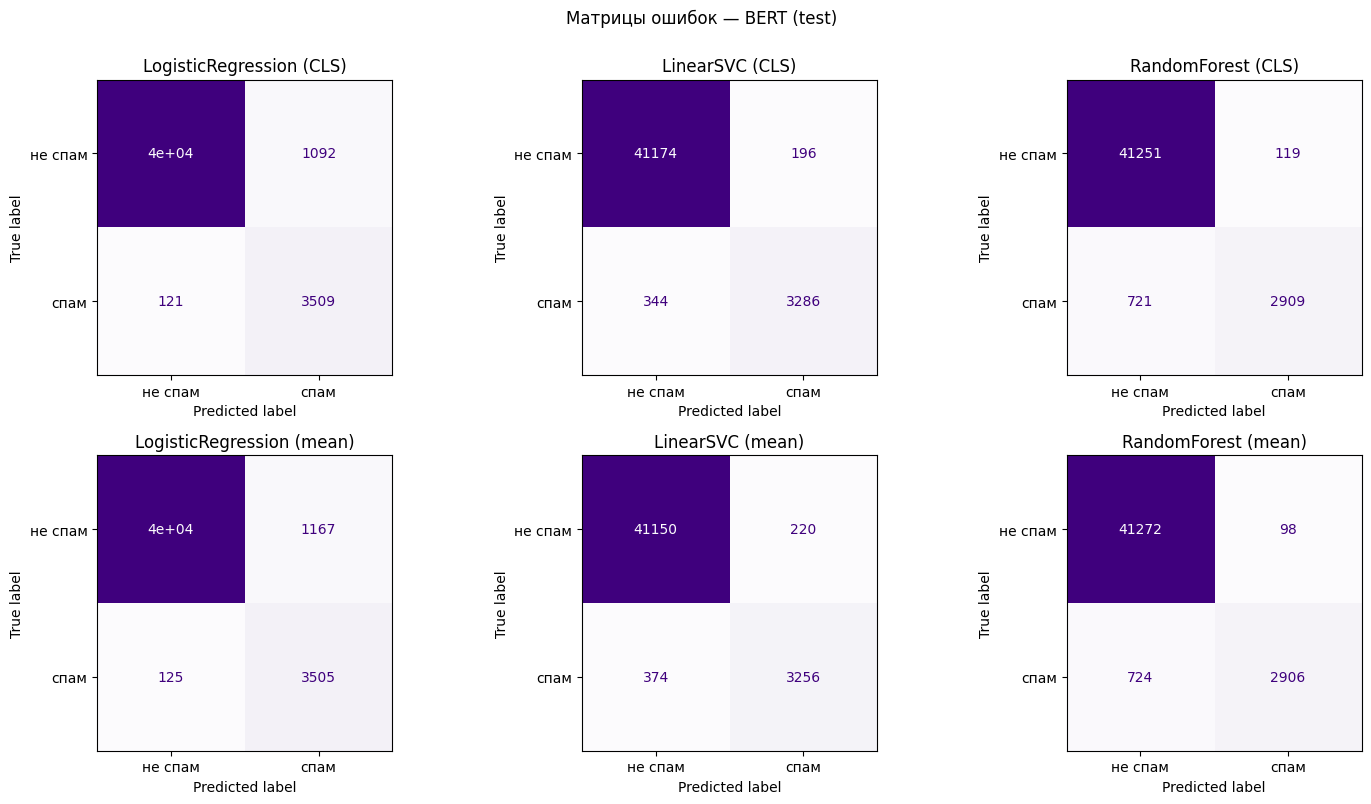

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

models_to_plot = [
    ("CLS", "LogisticRegression", cls_test),
    ("CLS", "LinearSVC", cls_test),
    ("CLS", "RandomForest", cls_test),
    ("mean", "LogisticRegression", mean_test),
    ("mean", "LinearSVC", mean_test),
    ("mean", "RandomForest", mean_test),
]

for ax, (pooling, name, X) in zip(axes.flat, models_to_plot):
    path = os.path.join(MODELS_DIR, f"{pooling}_{name.lower()}.pkl")
    with open(path, "rb") as f:
        clf = pickle.load(f)
    y_pred = clf.predict(X)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["не спам", "спам"]).plot(
        ax=ax, colorbar=False, cmap="Purples")
    ax.set_title(f"{name} ({pooling})")

plt.suptitle("Матрицы ошибок — BERT (test)", y=1.00)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "bert_confusion_matrices.png"),
            dpi=150, bbox_inches="tight")
plt.show()